# Ejercitario: análisis de visitas al portal de una biblioteca

Este trabajo práctico utiliza **Pandas, Matplotlib y Seaborn** para analizar las visitas diarias al portal web de una biblioteca escolar entre 2022 y 2025.

El dataset está incluido en el notebook y se genera automáticamente. Ejecute primero las celdas de preparación y luego resuelva las actividades.

**Puntaje sugerido:** 40 puntos — 10 actividades de 4 puntos cada una.

## Preparación del entorno y creación del dataset

In [1]:
# Librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [2]:
# Dataset incluido: se genera siempre con los mismos datos
rng = np.random.default_rng(2026)
fechas = pd.date_range('2022-01-01', '2025-12-31', freq='D')
n = len(fechas)
tendencia = np.linspace(80, 280, n)
estacionalidad = 38 * np.sin(2 * np.pi * fechas.dayofyear.to_numpy() / 365.25)
efecto_semana = np.where(fechas.dayofweek.to_numpy() < 5, 35, -25)
ruido = rng.normal(0, 22, n)
visitas = np.maximum(5, np.round(tendencia + estacionalidad + efecto_semana + ruido)).astype(float)

# Se agregan valores atípicos y faltantes para practicar limpieza
indices_atipicos = rng.choice(n, 14, replace=False)
visitas[indices_atipicos] *= rng.integers(3, 6, len(indices_atipicos))
indices_faltantes = rng.choice(np.setdiff1d(np.arange(n), indices_atipicos), 12, replace=False)
visitas[indices_faltantes] = np.nan

df = pd.DataFrame({'fecha': fechas, 'visitas': visitas})
df.head()

,fecha,visitas
0,2022-01-01,38.0
1,2022-01-02,62.0
2,2022-01-03,76.0
3,2022-01-04,149.0
4,2022-01-05,133.0


## Actividad 1 — Inspección inicial (4 puntos)
Muestre las primeras 10 y las últimas 5 filas. Luego indique cuántas filas y columnas posee el dataset.

In [3]:
# Escriba aquí su solución
# Primeras 10 filas
print("Primeras 10 filas:")
display(df.head(10))

# Últimas 5 filas
print("\nÚltimas 5 filas:")
display(df.tail(5))

# Cantidad de filas y columnas
print("\nDimensiones del dataset:")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Primeras 10 filas:


,fecha,visitas
0,2022-01-01,38.0
1,2022-01-02,62.0
2,2022-01-03,76.0
3,2022-01-04,149.0
4,2022-01-05,133.0
5,2022-01-06,113.0
6,2022-01-07,114.0
7,2022-01-08,68.0
8,2022-01-09,56.0
9,2022-01-10,118.0



Últimas 5 filas:


,fecha,visitas
1456,2025-12-27,260.0
1457,2025-12-28,218.0
1458,2025-12-29,296.0
1459,2025-12-30,351.0
1460,2025-12-31,335.0



Dimensiones del dataset:
Filas: 1461
Columnas: 2


## Actividad 2 — Tipos y calidad de datos (4 puntos)
Utilice `info()` y verifique el tipo de cada columna. Calcule cuántos valores faltantes existen por columna.

In [4]:
# Escriba aquí su solución
# Información general del dataset
print("Información del dataset:")
df.info()

# Tipo de cada columna
print("\nTipo de cada columna:")
print(df.dtypes)

# Valores faltantes por columna
print("\nValores faltantes por columna:")
print(df.isnull().sum())

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   fecha    1461 non-null   datetime64[us]
 1   visitas  1449 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 23.0 KB

Tipo de cada columna:
fecha      datetime64[us]
visitas           float64
dtype: object

Valores faltantes por columna:
fecha       0
visitas    12
dtype: int64


## Actividad 3 — Estadística descriptiva (4 puntos)
Obtenga las estadísticas descriptivas de `visitas`. Responda: ¿cuál es la media, la mediana, el mínimo y el máximo?

> Pista: combine `describe()` con `median()`.

In [5]:
# Escriba aquí su solución
# Estadísticas descriptivas de la columna visitas
print("Estadísticas descriptivas:")
print(df['visitas'].describe())

# Mediana
print("\nMediana:")
print(df['visitas'].median())

Estadísticas descriptivas:
count    1449.000000
mean      201.999310
std        84.245871
min         8.000000
25%       149.000000
50%       197.000000
75%       251.000000
max      1004.000000
Name: visitas, dtype: float64

Mediana:
197.0


## Actividad 4 — Tratamiento de valores faltantes (4 puntos)
Cree un nuevo DataFrame llamado `df_limpio` eliminando las filas con visitas faltantes. Compruebe que ya no existan valores nulos e indique cuántas filas se eliminaron. No modifique `df`.

In [6]:
# Escriba aquí su solución
# Crear un nuevo DataFrame eliminando los valores faltantes
df_limpio = df.dropna(subset=['visitas']).copy()

# Comprobar valores nulos
print("Valores nulos en df_limpio:")
print(df_limpio.isnull().sum())

# Indicar cuántas filas se eliminaron
filas_eliminadas = len(df) - len(df_limpio)
print(f"\nFilas eliminadas: {filas_eliminadas}")

Valores nulos en df_limpio:
fecha      0
visitas    0
dtype: int64

Filas eliminadas: 12


## Actividad 5 — Filtrado por percentiles (4 puntos)
A partir de `df_limpio`, elimine los días ubicados en el 2,5 % inferior y en el 2,5 % superior de visitas. Guarde el resultado en `df_filtrado` e indique cuántas filas quedaron.

> Pista: calcule los cuantiles `0.025` y `0.975`.

In [7]:
# Escriba aquí su solución
# Calcular los cuantiles
q_inferior = df_limpio['visitas'].quantile(0.025)
q_superior = df_limpio['visitas'].quantile(0.975)

# Filtrar los valores dentro de los percentiles
df_filtrado = df_limpio[
    (df_limpio['visitas'] >= q_inferior) &
    (df_limpio['visitas'] <= q_superior)
].copy()

# Mostrar los cuantiles y la cantidad de filas
print("Cuantil 2,5 %:", q_inferior)
print("Cuantil 97,5 %:", q_superior)
print("\nFilas que quedaron:", len(df_filtrado))

Cuantil 2,5 %: 67.0
Cuantil 97,5 %: 323.5999999999999

Filas que quedaron: 1376


## Actividad 6 — Gráfico de línea (4 puntos)
Realice un gráfico de línea con `df_filtrado`:

- Tamaño `(12, 5)`.
- Título: **Visitas diarias al portal de la biblioteca (2022–2025)**.
- Eje X: **Fecha**.
- Eje Y: **Cantidad de visitas**.
- Línea de color verde oscuro.

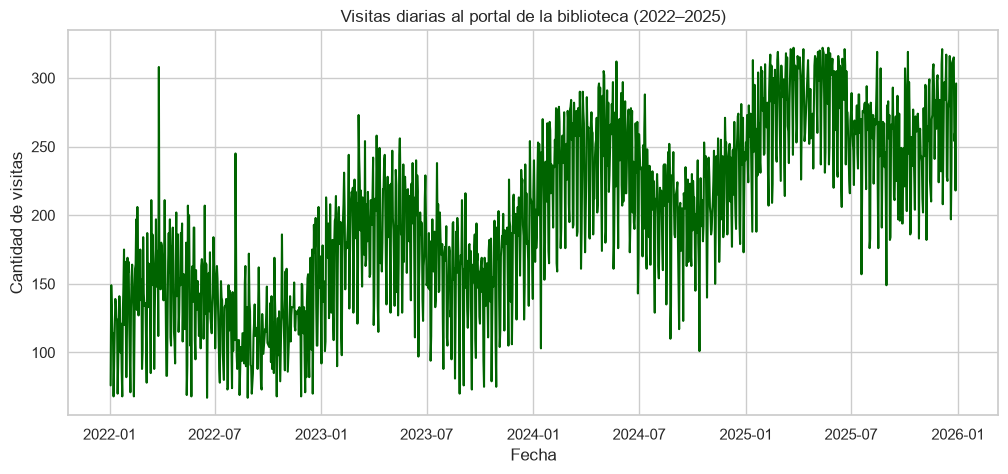

In [8]:
# Escriba aquí su solución
# Gráfico de línea
plt.figure(figsize=(12, 5))

plt.plot(
    df_filtrado['fecha'],
    df_filtrado['visitas'],
    color='darkgreen'
)

plt.title('Visitas diarias al portal de la biblioteca (2022–2025)')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de visitas')

plt.show()

## Actividad 7 — Distribución de visitas (4 puntos)
Construya un histograma de `visitas` usando `df_filtrado`. Agregue una curva KDE, 25 intervalos, título y etiquetas claras. Explique brevemente qué rango concentra la mayor cantidad de días.

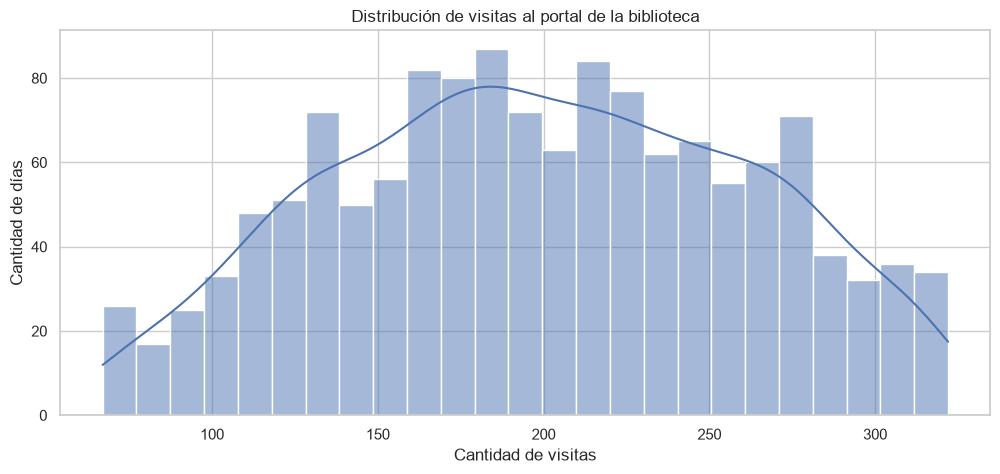

In [9]:
# Escriba aquí su solución
# Histograma de visitas con curva KDE
plt.figure(figsize=(12, 5))

sns.histplot(
    df_filtrado['visitas'],
    bins=25,
    kde=True
)

plt.title('Distribución de visitas al portal de la biblioteca')
plt.xlabel('Cantidad de visitas')
plt.ylabel('Cantidad de días')

plt.show()

## Actividad 8 — Columnas temporales y resumen anual (4 puntos)
Agregue a `df_filtrado` las columnas `año`, `mes` y `dia_semana`. Después, agrupe por año y calcule la suma y el promedio de visitas. Muestre el resumen resultante.

In [10]:
# Escriba aquí su solución
# Agregar columnas temporales
df_filtrado['año'] = df_filtrado['fecha'].dt.year
df_filtrado['mes'] = df_filtrado['fecha'].dt.month
df_filtrado['dia_semana'] = df_filtrado['fecha'].dt.day_name()

# Resumen anual: suma y promedio de visitas
resumen_anual = df_filtrado.groupby('año')['visitas'].agg(
    suma='sum',
    promedio='mean'
).reset_index()

# Mostrar el resumen
print("Resumen anual:")
display(resumen_anual)

Resumen anual:


,año,suma,promedio
0,2022,43149.0,132.766154
1,2023,62638.0,173.512465
2,2024,79833.0,222.997207
3,2025,88158.0,265.536145


## Actividad 9 — Comparación mensual por año (4 puntos)
Calcule el promedio de visitas por `año` y `mes`. Represente el resultado en un gráfico de barras:

- Eje X: año.
- Eje Y: promedio de visitas.
- Color (`hue`): mes.
- Leyenda titulada **Mes**.
- Etiquetas del eje X giradas 45°.

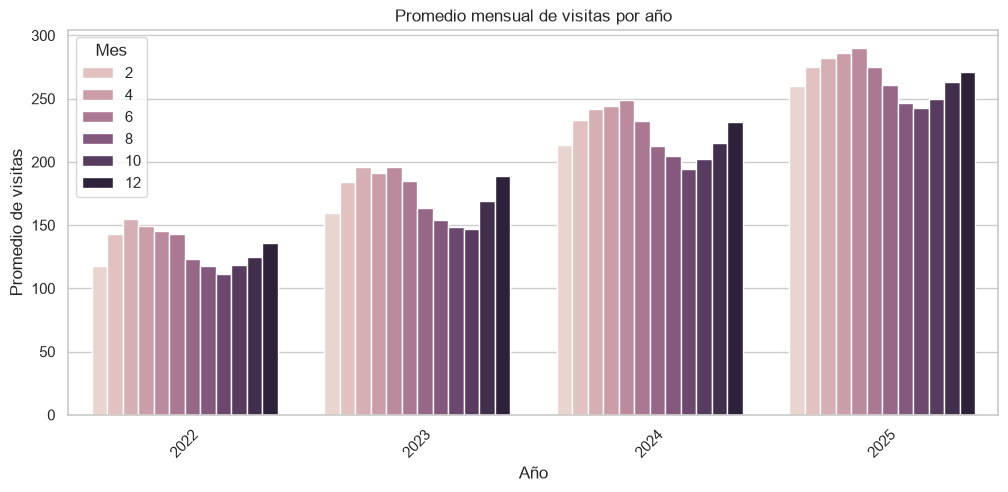

In [11]:
# Escriba aquí su solución
# Promedio de visitas por año y mes
promedio_mensual = df_filtrado.groupby(
    ['año', 'mes']
)['visitas'].mean().reset_index()

# Gráfico de barras
plt.figure(figsize=(12, 5))

sns.barplot(
    data=promedio_mensual,
    x='año',
    y='visitas',
    hue='mes'
)

plt.title('Promedio mensual de visitas por año')
plt.xlabel('Año')
plt.ylabel('Promedio de visitas')

plt.legend(title='Mes')
plt.xticks(rotation=45)

plt.show()

## Actividad 10 — Diagramas de caja e interpretación (4 puntos)
Cree dos diagramas de caja adyacentes mediante `subplots`:

1. Visitas por año.
2. Visitas por mes.

Use un tamaño total de `(14, 6)`, títulos y etiquetas. Finalmente, escriba dos conclusiones basadas en los gráficos.

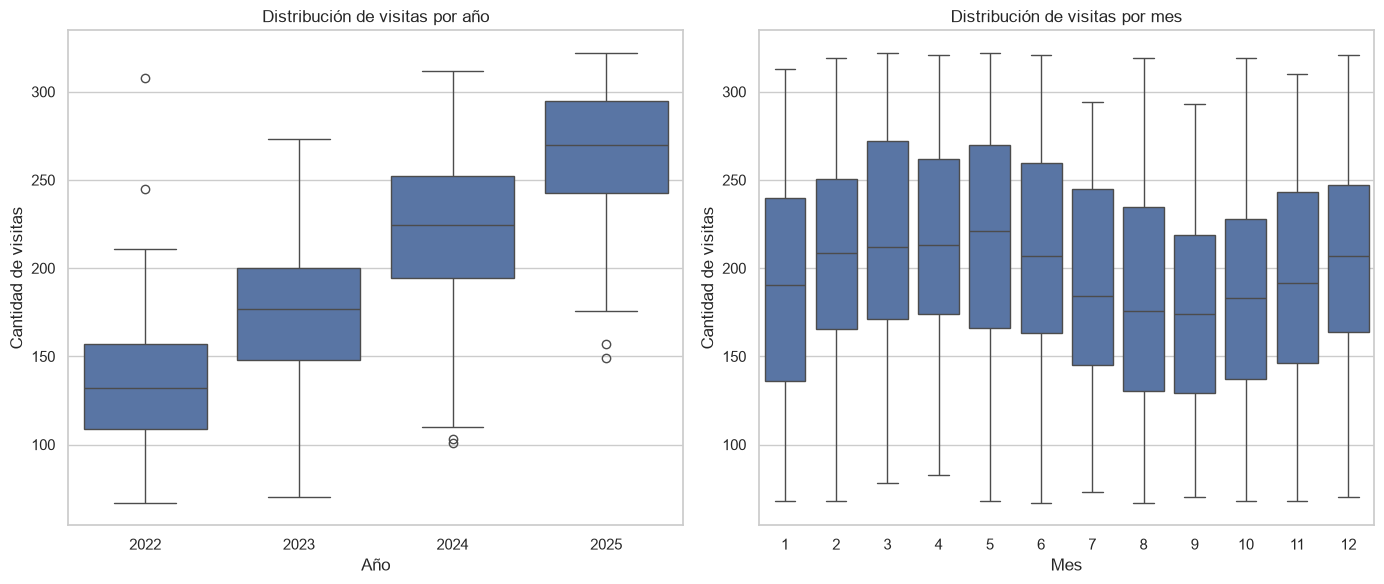

In [12]:
# Escriba aquí su solución
# Crear dos diagramas de caja adyacentes
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Visitas por año
sns.boxplot(
    data=df_filtrado,
    x='año',
    y='visitas',
    ax=axes[0]
)

axes[0].set_title('Distribución de visitas por año')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Cantidad de visitas')

# 2. Visitas por mes
sns.boxplot(
    data=df_filtrado,
    x='mes',
    y='visitas',
    ax=axes[1]
)

axes[1].set_title('Distribución de visitas por mes')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Cantidad de visitas')

plt.tight_layout()
plt.show()

# Escriba aquí sus conclusiones como comentario o convierta esta celda a Markdown
### Se observa una diferencia en la distribución de las visitas entre los distintos años.
### Algunos años presentan una mayor cantidad de visitas y una mayor variabilidad que otros.
### Los diagramas también permiten identificar posibles valores atípicos en las visitas registradas.
### En cuanto a los meses, la cantidad de visitas no se distribuye de manera uniforme durante todo el año.
### Algunos meses concentran valores más altos de visitas, mientras que otros presentan valores inferiores.
### En general, los gráficos permiten comparar tanto la evolución anual como el comportamiento mensual de las visitas.